In [1]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia
from boulder_statistics.analysis.fit_params.power_law_fit_params import PowerLawFitParams
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable


from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
df_cut = pl.read_parquet(
    "multi_LAD_min_fit_data"
).filter(
    pl.col("q").is_not_nan()
).with_columns(
    (- 2 * pl.col("q")).alias("q") # Fix issues with different definitions in the models
).group_by("LAD_min").agg(
    pl.col("q").mean().alias("q_mean"),
    pl.col("q").std().alias("q_err"),

    pl.col("g_mu").mean().alias("g_mu_mean"),
    pl.col("g_mu").std().alias("g_mu_err"),

    pl.col("g_std").mean().alias("g_std_mean"),
    pl.col("g_std").std().alias("g_std_err"),
).sort(
    "LAD_min"
) #.filter(
    # Remove the items right at the edge
 #   ((pl.col("LAD_min") < 0.2) & (1 / pl.col("g_mu_mean") > 1.4)).not_()
#)

df_cut

LAD_min,q_mean,q_err,g_mu_mean,g_mu_err,g_std_mean,g_std_err
f64,f64,f64,f64,f64,f64,f64
0.050919,-1.730501,0.075454,0.626743,0.002899,0.103503,0.00125
0.051642,-1.68795,0.061119,0.628597,0.003954,0.104134,0.00099
0.065927,-1.717629,0.111013,0.626677,0.006856,0.103548,0.001225
0.066489,-1.603372,0.084621,0.628351,0.008078,0.105268,0.002643
0.070862,-1.700495,0.128611,0.6242,0.009109,0.103731,0.001741
…,…,…,…,…,…,…
8.294585,-2.818728,0.061109,0.580162,0.002016,0.131797,0.001086
8.328855,-2.851858,0.046862,0.577053,0.001503,0.130361,0.001048
8.66453,-2.808287,0.134792,0.567178,0.001431,0.129297,0.00144


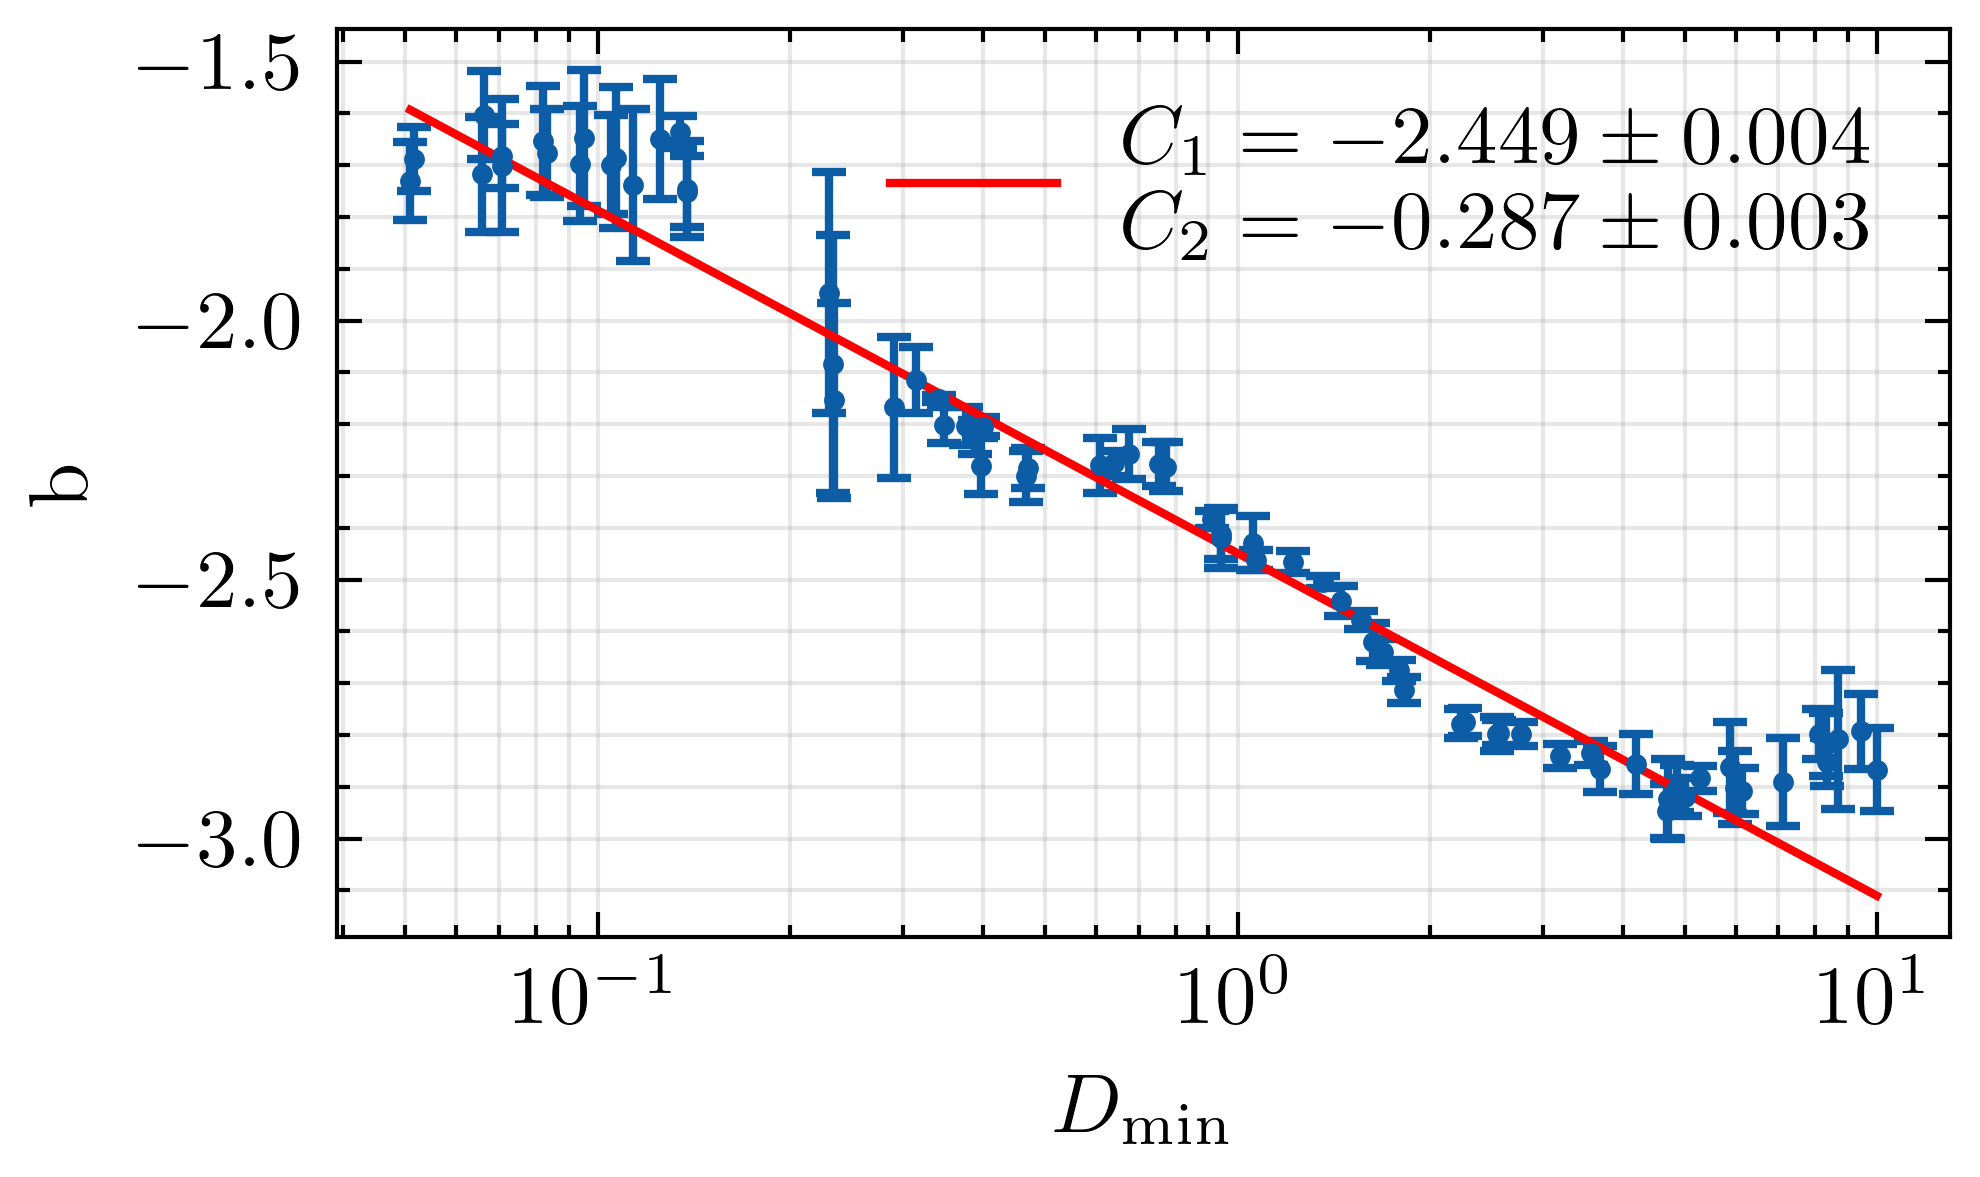

C1 = -2.448946 ± 0.003540
C2 = -0.287440 ± 0.003469
R² = 0.946280


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

# Model
def log_model(x, C1, C2):
    return C1 + C2 * np.log(x)

# Data
x = df_cut["LAD_min"].to_numpy()
y = df_cut["q_mean"].to_numpy()
yerr = df_cut["q_err"].to_numpy()

# Weighted fit
popt, pcov = curve_fit(
    log_model,
    x,
    y,
    sigma=yerr,
    absolute_sigma=True
)

C1, C2 = popt
C1_err, C2_err = np.sqrt(np.diag(pcov))

# Smooth curve
xfit = np.linspace(x.min(), x.max(), 300)
yfit = log_model(xfit, *popt)

plt.errorbar(
    x,
    y,
    yerr=yerr,
    fmt='.',
    capsize=2,
    ms=3
)

plt.plot(
    xfit,
    yfit,
    'r',
    label=(
        rf"$C_1 = {C1:.3f} \pm {C1_err:.3f}$" "\n"
        rf"$C_2 = {C2:.3f} \pm {C2_err:.3f}$"
    )
)

plt.xscale("log")
plt.xlabel(r"$D_{\min}$")
plt.ylabel("b")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()

plt.savefig(".plots/b_vs_LAD_min.png", dpi=300)
plt.show()

# Predictions at the data points
y_pred = log_model(x, *popt)

# R²
r2 = r2_score(y, y_pred)

print(f"C1 = {C1:.6f} ± {C1_err:.6f}")
print(f"C2 = {C2:.6f} ± {C2_err:.6f}")
print(f"R² = {r2:.6f}")

C:\Users\Joshu\AppData\Local\Temp\ipykernel_15012\2749318160.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


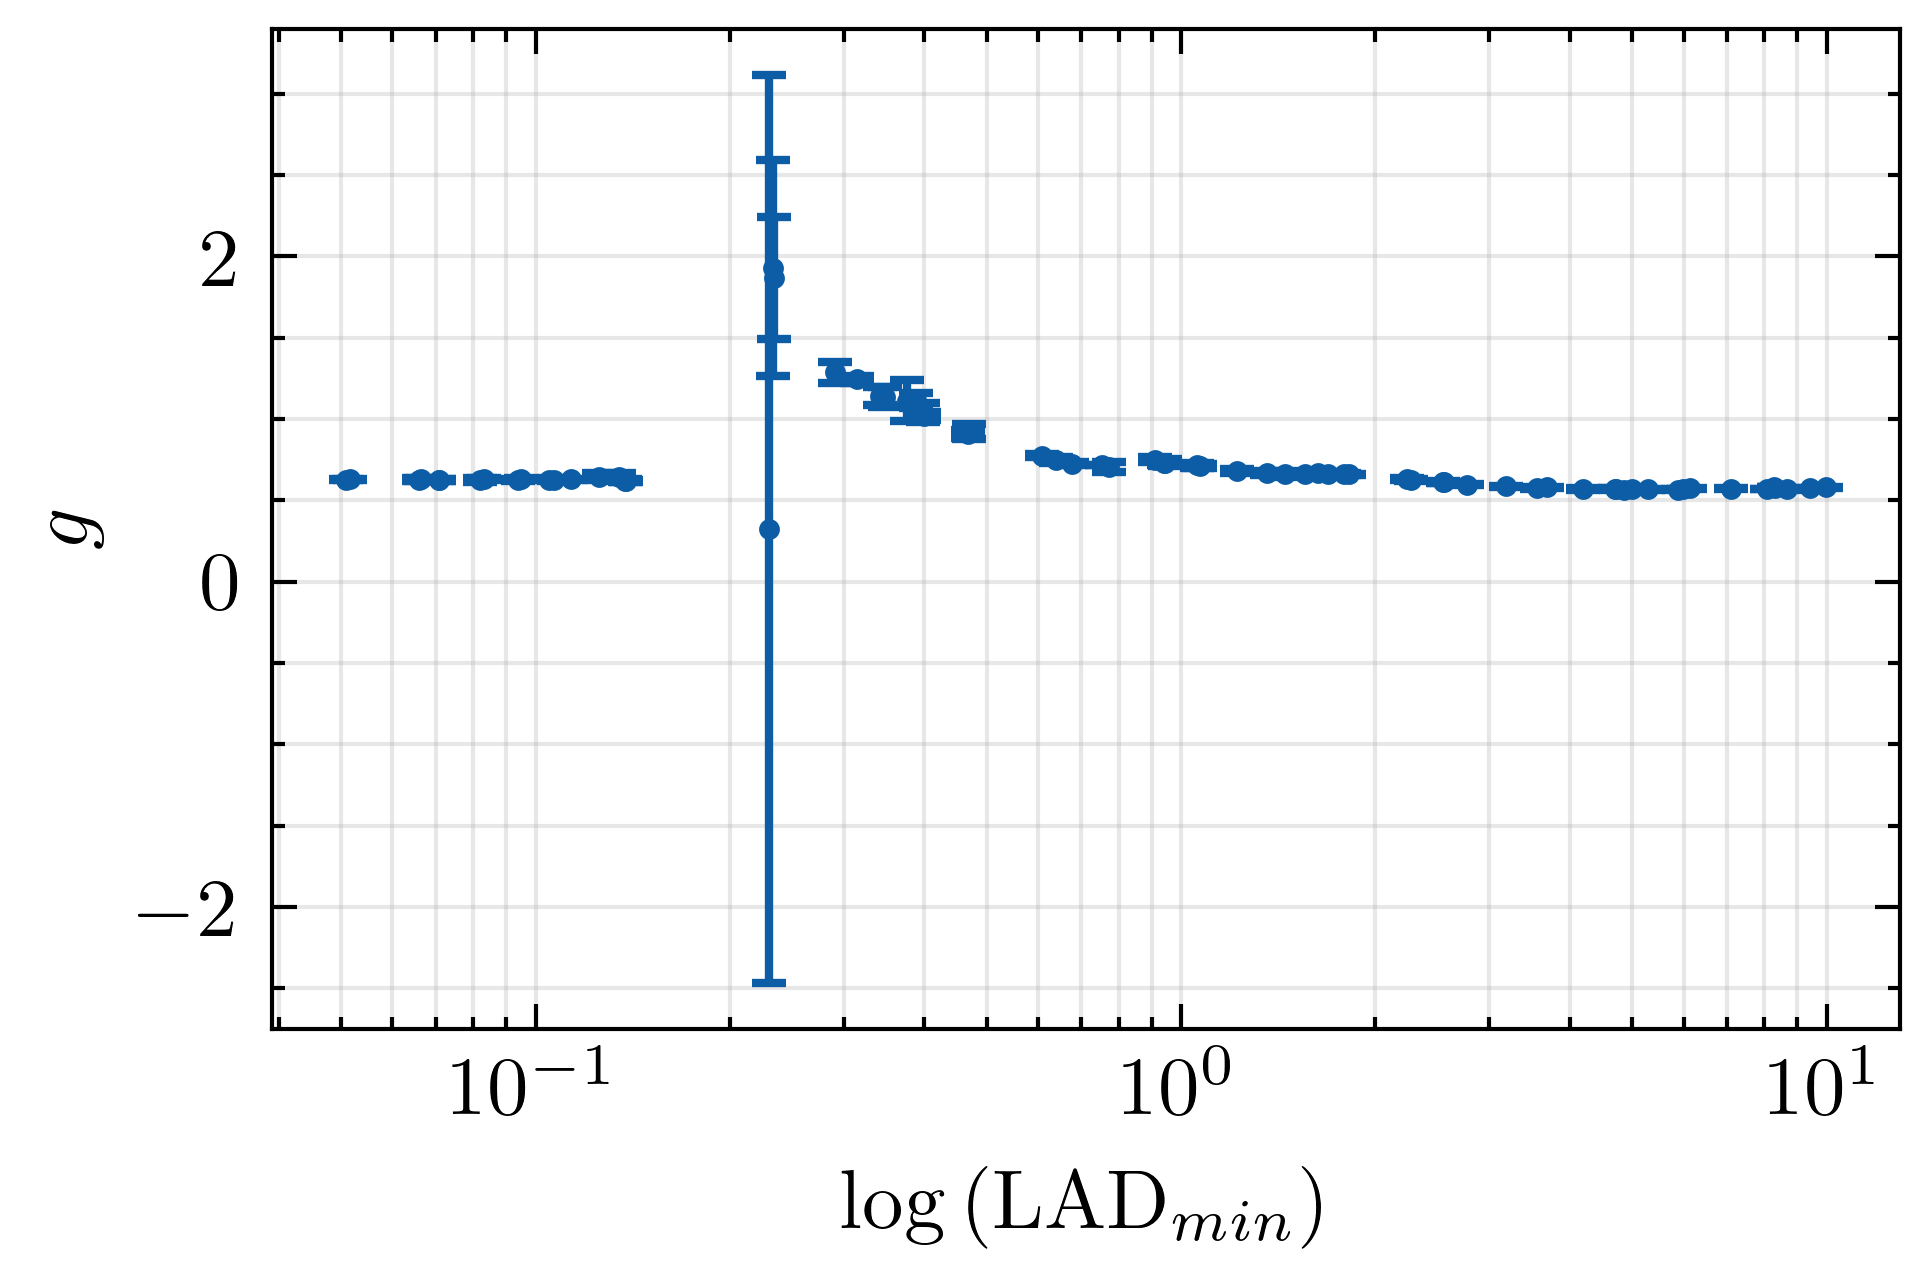

In [7]:
plt.errorbar(
        df_cut["LAD_min"],
        df_cut["g_mu_mean"],
        yerr= df_cut["g_mu_err"], # Error prop
        marker=".",
        capsize=2,
        linestyle="none",
        ms = 3
    )

plt.xscale("log")
plt.xlabel(r"$\log{(\text{LAD}_{min})}$")
plt.ylabel(r"$g$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# phi_agg_dfs = []

# for face in dp.boulder_agg_data.select("tile_face").unique().collect()["tile_face"]:
#     phis = dp.Phi_mesh.filter(pl.col("face") == face).collect()
#     mac = dp.mask_atlas_combined.filter(pl.col("face") == face).collect()

#     joint = mac.join(phis, on = ["face", "i", "j"], how="inner").select(
#         ["face", "i", "j", "row_id", "area"]
#     ).group_by(["row_id"]).agg(
#         pl.col("area").sum()
#     )

#     phi_agg_dfs.append(joint)

# phi_agg_df = pl.concat(phi_agg_dfs)

# phi_agg_df.write_parquet("phi_agg_df.parquet")
phi_agg_df = pl.read_parquet("phi_agg_df.parquet").with_columns(
    (pl.col("area") * 1e6).alias("area_m_sqr")
)

phi_agg_df

row_id,area,area_m_sqr
u32,f32,f32
1452761,5.9158e-7,0.591575
751089,5.0752e-8,0.050752
813368,9.2610e-8,0.09261
727509,0.000012,12.134059
3396152,6.5128e-8,0.065128
…,…,…
3234122,1.4833e-7,0.148327
1872984,5.3261e-9,0.005326
1823451,1.3778e-7,0.137779


In [ ]:
gamma_df = dp.boulder_agg_data.collect().join(phi_agg_df, on="row_id", how="inner").with_columns(
    (1e3 * pl.col("longest_axis_diameter")).alias("longest_axis_diameter_m")
).with_columns(
    (np.pi * (pl.col("longest_axis_diameter_m") / 2) ** 2).alias("LAD_based_area")
).with_columns(
    (pl.col("LAD_based_area") / pl.col("area_m_sqr")).alias("Gamma"),
    (pl.col("area_m_sqr") / pl.col("alpha")).alias("Phi"),
).filter(pl.col("Gamma") > 0, pl.col("Gamma") < 6) # Remove unrealistic values

gamma_df

row_id,tile_face,tile_lod_number,tile_lod_code,longest_axis_diameter,surface_area,mean_i,mean_j,max_i,max_j,min_i,min_j,mean_position_x,mean_position_y,mean_position_z,alpha,lod_level,lod_code,area,area_m_sqr,longest_axis_diameter_m,LAD_based_area,Gamma,Phi
u32,str,i64,str,f32,f32,f64,f64,u32,u32,u32,u32,f32,f32,f32,u32,u8,str,f32,f32,f32,f32,f32,f64
1452761,"""posx""",4,"""BCAA""",0.001098,0.000001,2313.839623,4279.853774,2321,4289,2306,4271,0.010061,-0.22303,-0.09704,212,4,"""BCAA""",5.9158e-7,0.591575,1.098352,0.947486,1.601633,0.00279
751089,"""posx""",4,"""ADAA""",0.000224,6.8698e-8,2207.1,2540.95,2209,2543,2205,2539,-0.079473,-0.209466,-0.096595,20,4,"""ADAA""",5.0752e-8,0.050752,0.223792,0.039335,0.775042,0.002538
813368,"""posx""",4,"""ADBB""",0.000381,1.4329e-7,2252.65625,3872.875,2256,3875,2249,3870,-0.012216,-0.225185,-0.101341,32,4,"""ADBB""",9.2610e-8,0.09261,0.380666,0.11381,1.228909,0.002894
727509,"""posx""",2,"""AD""",0.005042,0.000025,3224.5,3830.1,3255,3863,3192,3788,-0.016015,-0.247557,-0.052666,3200,2,"""AD""",0.000012,12.134059,5.041579,19.962872,1.645193,0.003792
3396152,"""posx""",4,"""DBDC""",0.000338,9.8776e-8,5691.973684,7252.894737,5694,7257,5690,7249,0.148804,-0.192997,0.075203,38,4,"""DBDC""",6.5128e-8,0.065128,0.33815,0.089807,1.378928,0.001714
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3234122,"""posy""",4,"""DBAD""",0.00047,2.5669e-7,5110.784091,7076.261364,5115,7081,5106,7071,0.045918,-0.134764,0.185155,88,4,"""DBAD""",1.4833e-7,0.148327,0.469561,0.173171,1.167495,0.001686
1872984,"""posy""",3,"""BDD""",0.000053,2.5576e-9,3610.5,7818.5,3611,7819,3610,7818,-0.020516,-0.157621,0.173377,4,3,"""BDD""",5.3261e-9,0.005326,0.052883,0.002196,0.412388,0.001332
1823451,"""posy""",4,"""BDCA""",0.000499,2.3965e-7,3310.704225,6549.084507,3314,6555,3307,6543,-0.037444,-0.117105,0.195447,71,4,"""BDCA""",1.3778e-7,0.137779,0.498727,0.195351,1.417853,0.001941


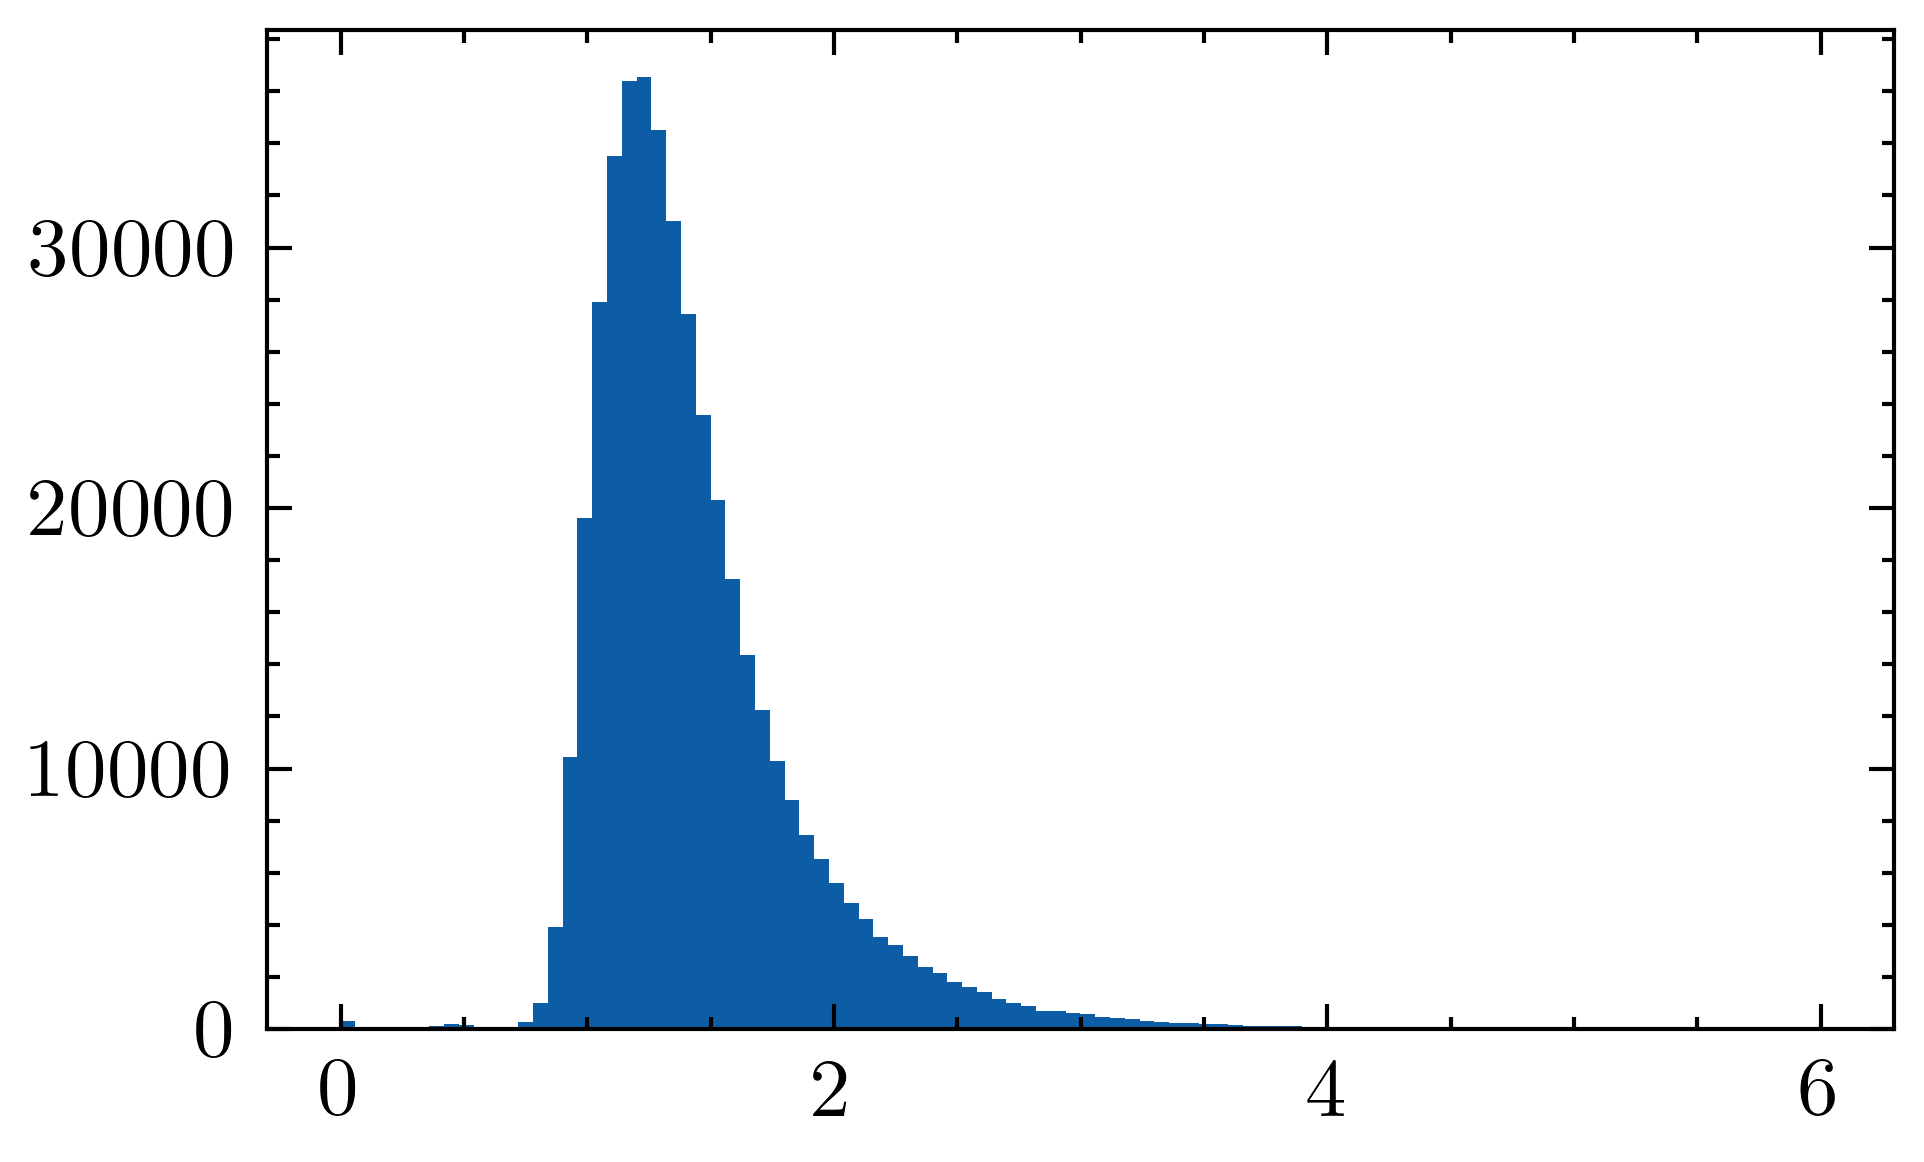

In [ ]:
_ = plt.hist(gamma_df["Gamma"], 100)

In [ ]:
# vals = gamma_df["area_m_sqr"]
# _ = plt.hist(gamma_df["area_m_sqr"], np.geomspace(vals.min(), 100, 100))

# plt.xscale("log")

In [ ]:
def Cleaned_Phi():
    bin_centers = 0.5 * \
        (dp.Phi_counts_smoothed_bins[:-1] +
            dp.Phi_counts_smoothed_bins[1:])

    bin_widths = np.abs(
        dp.Phi_counts_smoothed_bins[:-1] - dp.Phi_counts_smoothed_bins[1:])

    mask: np.ndarray = (dp.Phi_counts_smoothed_counts / bin_widths > 10**3
                        ) & (dp.Phi_counts_smoothed_counts * bin_widths > 10**3)

    return bin_centers[mask], dp.Phi_counts_smoothed_counts[mask]

centers, counts = Cleaned_Phi()

In [ ]:
# LAD_mins_bins = np.geomspace(0.1, 2, 50)

# g_vals = []
# LAD_min_vals = []

# for LAD_min_left, LAD_min_right in zip(LAD_mins_bins[:-1], LAD_mins_bins[1:]):
#     most = gamma_df.filter(
#         pl.col("longest_axis_diameter_m") > LAD_min_left,
#         pl.col("longest_axis_diameter_m") < LAD_min_right,
#         )

#     most_ratios = most["longest_axis_diameter"].to_numpy(
#     ) / most["surface_area"].to_numpy()
#     most_ratios_clean = most_ratios[~np.isnan(most_ratios)]

#     mean_p2std = most_ratios_clean.mean() + 2 * most_ratios_clean.std()

#     clean_df = gamma_df.filter(
#         pl.col("longest_axis_diameter_m") > LAD_min_left,
#         pl.col("longest_axis_diameter_m") < LAD_min_right,
#         (pl.col("longest_axis_diameter") /
#             pl.col("surface_area")) < mean_p2std,
#             pl.col("alpha") > 20
#     )

#     # alpha_min = clean_df.filter(pl.col("alpha") == pl.col("alpha").min())
#     if clean_df.height == 0:
#         continue

#     lad_min_mid_val = np.exp(0.5 * (np.log(LAD_min_left) + np.log(LAD_min_right)))

#     g_vals.append((1 / centers.min()) * (np.pi / 4) / np.median((clean_df["Phi"] * clean_df["Gamma"]).to_numpy()))
#     LAD_min_vals.append(LAD_min_left)

# g = np.array(g_vals, dtype=np.float64)

# plt.errorbar(
#         df_cut["LAD_min"],
#         1 / df_cut["g_mean"],
#         yerr= df_cut["g_err"] / (df_cut["g_mean"]), # Error prop
#         marker=".",
#         capsize=2,
#         linestyle="none",
#         ms = 3
#     )

# plt.plot(LAD_min_vals, 3.5 / g) # Why 4?

# # plt.ylim([1 / df_cut["g_mean"].max(), 1 / df_cut["g_mean"].min()])
# plt.xlim([df_cut["LAD_min"].min(), df_cut["LAD_min"].max()])
# plt.yscale("log")
# plt.xscale("log")
# plt.xlabel(r"$\log{(\text{LAD}_{min})}$")
# plt.ylabel(r"$\frac{1}{g}$")
# plt.grid(True, which="both", alpha=0.3)
# plt.legend()
# plt.savefig(".plots/g_vs_LAD_min.png")
# plt.show()

In [ ]:
# LAD_mins_bins = np.geomspace(0.1, 4, 50)

# g_vals = []
# LAD_min_vals = []

# for LAD_min_left, LAD_min_right in zip(LAD_mins_bins[:-1], LAD_mins_bins[1:]):
#     most = gamma_df.filter(
#         pl.col("longest_axis_diameter_m") > LAD_min_left,
#         pl.col("longest_axis_diameter_m") < LAD_min_right,
#         )

#     most_ratios = most["longest_axis_diameter"].to_numpy(
#     ) / most["surface_area"].to_numpy()
#     most_ratios_clean = most_ratios[~np.isnan(most_ratios)]

#     mean_p2std = most_ratios_clean.mean() + 2 * most_ratios_clean.std()

#     clean_df = gamma_df.filter(
#         pl.col("longest_axis_diameter_m") > LAD_min_left,
#         pl.col("longest_axis_diameter_m") < LAD_min_right,
#         (pl.col("longest_axis_diameter") /
#             pl.col("surface_area")) < mean_p2std,
#             pl.col("alpha") > 20
#     )

#     # alpha_min = clean_df.filter(pl.col("alpha") == pl.col("alpha").min())
#     if clean_df.height == 0:
#         continue

#     lad_min_mid_val = np.exp(0.5 * (np.log(LAD_min_left) + np.log(LAD_min_right)))

#     g_vals.append(clean_df["alpha"].mean() / (centers.min() * (lad_min_mid_val ** 2)))
#     LAD_min_vals.append(lad_min_mid_val)

# g = np.array(g_vals, dtype=np.float64)

# plt.errorbar(
#         df_cut["LAD_min"],
#         1 / df_cut["g_mean"],
#         yerr= df_cut["g_err"] / (df_cut["g_mean"]), # Error prop
#         marker=".",
#         capsize=2,
#         linestyle="none",
#         ms = 3
#     )

# plt.plot(LAD_min_vals, 4 / g) # Why 4?

# # plt.ylim([1 / df_cut["g_mean"].max(), 1 / df_cut["g_mean"].min()])
# # plt.xlim([df_cut["LAD_min"].min(), df_cut["LAD_min"].max()])
# # plt.yscale("log")
# plt.xscale("log")
# plt.xlabel(r"$\log{(\text{LAD}_{min})}$")
# plt.ylabel(r"$\frac{1}{g}$")
# plt.grid(True, which="both", alpha=0.3)
# plt.legend()
# plt.savefig(".plots/g_vs_LAD_min.png")
# plt.show()

C:\Users\Joshu\AppData\Local\Temp\ipykernel_4624\4293157481.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


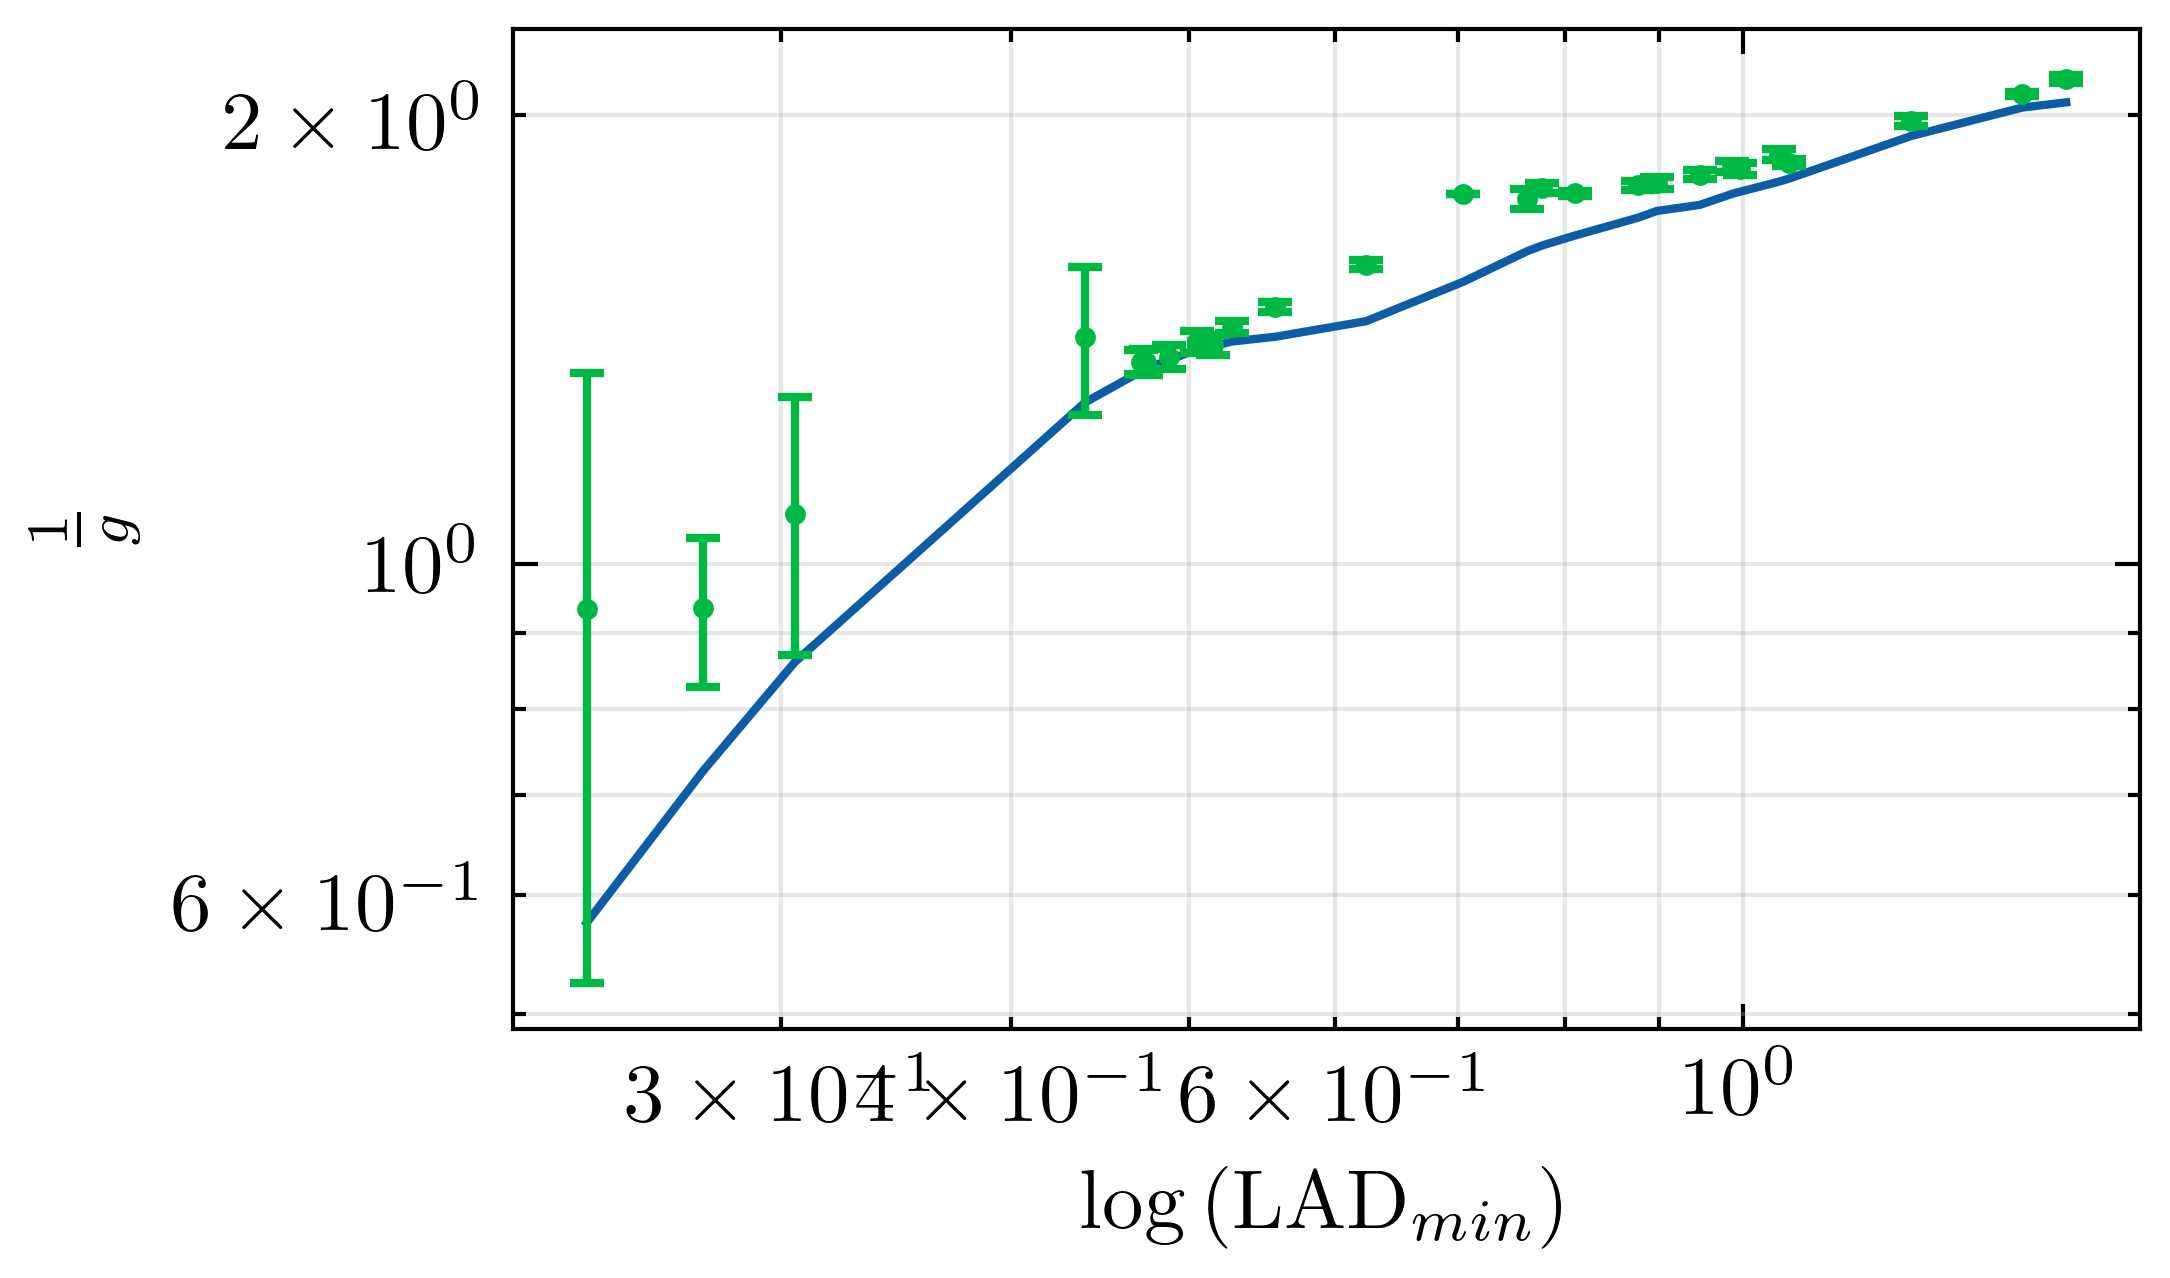

In [ ]:
LAD_mins = df_cut["LAD_min"] #  np.geomspace(0.02, 2, 100)

g_vals = []

for LAD_min, b_mean in zip(df_cut["LAD_min"], df_cut["q_mean"]):
    df = gamma_df.filter(pl.col("longest_axis_diameter") * 1e3 > LAD_min) 

    num = df.with_columns(
        ((pl.col("area_m_sqr")**(b_mean / 2 + 1) * pl.col("alpha").cast(pl.Float32()) ** (b_mean / 2 - 1)) \
        * (np.pi / (4 * (LAD_min ** 2))) * (pl.col("longest_axis_diameter_m") ** 2) / pl.col("Gamma")).alias("g_comp")
    )["g_comp"].median()

    denom = (df["area_m_sqr"]**(b_mean / 2 + 1) * df["alpha"].cast(pl.Float32()) ** (b_mean / 2 - 1)).median()

    g_vals.append(num / denom)

g = np.array(g_vals, dtype=np.float64)

plt.plot(LAD_mins, 1.8/g)

plt.errorbar(
        df_cut["LAD_min"],
        1 / df_cut["g_mean"],
        yerr= df_cut["g_err"] / (df_cut["g_mean"]), # Error prop
        marker=".",
        capsize=2,
        linestyle="none",
        ms = 3
    )

plt.yscale("log")
plt.xscale("log")
plt.xlabel(r"$\log{(\text{LAD}_{min})}$")
plt.ylabel(r"$\frac{1}{g}$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.savefig(".plots/g_vs_LAD_min.png")
plt.show()

In [ ]:
df = dp.boulder_agg_data.with_columns(
    (pl.col("alpha") / ((1e3 * pl.col("longest_axis_diameter")) ** 2)).alias("omega")
).collect()

r_act = (np.pi / 4) * (1 / df["omega"]) / (area * (1e3 ** 2))

_ = plt.hist(r_act, np.geomspace(r_act.min(), r_act.max(), 300))
plt.xscale("log")

NameError: name 'area' is not defined